In [ ]:
#install pandas
%pip install pandas
#install numpy
%pip install numpy
#install matplotlib
%pip install matplotlib
#install seaborn
%pip install seaborn
#install requests
%pip install requests
#install requests
%pip install aiohttp
#install tqdm
%pip install tqdm
#install geopandas
%pip install geopandas
#install contextily
%pip install contextily
#install dask
%pip install dask
%pip install --quiet dask pyarrow
#install time
%pip install time
#install country_converter
%pip install country_converter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/pip/__main__.py", line 24, in <module>
    sys.exit(_main())
             ^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/site-packages/pip/_internal/commands/__init__.py", line 121, in create_command
    module = importlib.import_module(module_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import aiohttp
import time
import dask.dataframe as dd

In [2]:
from datetime import datetime, timedelta
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO
from tqdm.auto import tqdm

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Define the start and end dates (6 primeros meses del 2021)
start_date = '2020-01-22'
end_date = '2021-12-26'

date_range = pd.date_range(start=start_date, end=end_date)

urls = [f'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_daily_reports/{single_date.strftime("%m-%d-%Y")}.csv' for single_date in date_range]
df_list = []

In [ ]:
# Importar 2020 y 2021 - forma 1

# Definir lista de DF's y tiempo inicial de carga
start_time = time.time()

for url in urls:
    df_list.append(pd.read_csv(url))

# Combinar los DataFrames diarios en uno solo.
df = pd.concat(df_list, ignore_index=True)

# Calcular tiempo de carga
load_time_1 = time.time() - start_time
print(f"Tiempo de carga: {load_time_1:.2f} s")

Tiempo de carga: 36.82 s


In [4]:
# Importar 2020 y 2021 - forma 2 (con Dask)

# Definir lista de DF's y tiempo inicial de carga
start_time = time.time()

# Leer todos los archivos en paralelo con Dask
df = dd.read_csv(urls, dtype={'Admin2': 'object', 'FIPS': 'object'}, 
                 assume_missing=True,
                 on_bad_lines='skip')

# Calcular tiempo de carga
load_time_2 = time.time() - start_time
print(f"Tiempo de carga con Dask: {load_time_2:.2f} s")

Tiempo de carga con Dask: 37.90 s


In [ ]:
# Uso de memoria antes de conversión de tipos

df_pd = df.compute()

# Verificar memoria usada por el DataFrame pandas resultante
memoria = df_pd.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memoria usada del DataFrame: {memoria:.2f} MB")

Memoria usada del DataFrame: 571.26 MB


In [5]:
def clean_covid_dask_df(ddf):
    """
    Limpia un Dask DataFrame de COVID-19 sin convertir a pandas.
    Normaliza columnas, aplica mapeo, y retorna Dask DataFrame limpio.
    """
    # Normalizar nombres de columnas
    ddf = ddf.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))
    
    # Obtener lista de columnas actuales
    current_cols = ddf.columns.tolist()
    
    # Mapeo conservador: variantes -> target
    col_map = {
        'country/region': 'country_region',
        'province/state': 'province_state',
        'confirmed_cases': 'confirmed',
        'confirmed_case': 'confirmed',
        'lastupdate': 'last_update',
    }
    
    # Aplicar renombrado solo si la variante existe y target no existe
    rename_dict = {}
    for src, tgt in col_map.items():
        if src in current_cols and tgt not in current_cols:
            rename_dict[src] = tgt
    
    if rename_dict:
        ddf = ddf.rename(columns=rename_dict)
        current_cols = ddf.columns.tolist()
    
    # Asegurar columnas clave (agregar si faltan)
    for col in ['confirmed', 'deaths', 'recovered', 'active', 'country_region', 'last_update']:
        if col not in current_cols:
            if col in ('active', 'last_update'):
                ddf[col] = np.nan
            elif col == 'country_region':
                ddf[col] = ''
            else:
                ddf[col] = 0
    
    # Convertir tipos numéricos (Dask soporta astype directo)
    for num_col in ['confirmed', 'deaths', 'recovered']:
        if num_col in ddf.columns:
            ddf[num_col] = ddf[num_col].fillna(0).astype('int64')
    
    # Calcular active si falta o es inválido
    if 'active' in ddf.columns:
        ddf['active'] = ddf['active'].fillna(0)
        # Donde active <= 0, recalcular
        confirmed_val = ddf['confirmed'].fillna(0)
        deaths_val = ddf['deaths'].fillna(0)
        recovered_val = ddf['recovered'].fillna(0) if 'recovered' in ddf.columns else 0
        
        calculated_active = confirmed_val - deaths_val - recovered_val
        ddf['active'] = ddf['active'].where(ddf['active'] > 0, calculated_active)
        ddf['active'] = ddf['active'].clip(lower=0).astype('int64')
    
    # Normalizar país (reemplazos simples)
    if 'country_region' in ddf.columns:
        ddf['country_region'] = ddf['country_region'].fillna('').astype(str)
        ddf['country_region'] = ddf['country_region'].replace({
            'US': 'United States',
            'Mainland China': 'China'
        })
    
    # Convertir fecha report_date (si existe) o usar last_update
    if 'report_date' in ddf.columns:
        ddf['report_date'] = dd.to_datetime(ddf['report_date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    elif 'last_update' in ddf.columns:
        ddf['report_date'] = dd.to_datetime(ddf['last_update'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
    
    # Eliminar columnas innecesarias si existen
    cols_to_drop = [c for c in ['fips', 'admin2', 'lat', 'long_', 'combined_key'] 
                    if c in ddf.columns]
    if cols_to_drop:
        ddf = ddf.drop(columns=cols_to_drop)
    
    return ddf

# Aplicar limpieza al Dask DataFrame
df = clean_covid_dask_df(df)

print("DataFrame Dask limpio.")
print(f"Columnas: {df.columns.tolist()}")

DataFrame Dask limpio.
Columnas: ['province_state', 'country_region', 'last_update', 'confirmed', 'deaths', 'recovered', 'active', 'report_date']


In [6]:
# Uso de memoria después de conversión de tipos

# Convertir columnas a tipos más eficientes
df['province_state'] = df['province_state'].astype('category')
df['country_region'] = df['country_region'].astype('category')

df_pd = df.compute()

# Verificar memoria usada por el DataFrame pandas resultante
memoria_optimizacion = df_pd.memory_usage(deep=True).sum() / (1024 * 1024)
print(f"Memoria usada del DataFrame tras optimización: {memoria_optimizacion:.2f} MB")

Memoria usada del DataFrame tras optimización: 190.41 MB


In [ ]:
print(f"Diferencia en uso de memoria: {(-(memoria - memoria_optimizacion) * 100 / memoria):.0f}%")

Diferencia en uso de memoria: -67%


In [7]:
df = df.compute()

In [8]:
cache_path = os.path.join(os.getcwd(), "data")
clean_path = os.path.join(cache_path, "covid_2020_2021_clean.parquet")
df.to_parquet(clean_path, index=False)

In [ ]:
sns.set(style="whitegrid", context="talk")

# Helper: buscar columna por variantes (case-insensitive)
def find_col(df, candidates):
    for cand in candidates:
        for c in df.columns:
            if c.lower() == cand.lower():
                return c
    return None

# Normalizar/renombrar columnas a nombres esperados
col_candidates = {
    'confirmed': ['confirmed','confirmed_cases','confirmed_case'],
    'deaths': ['deaths'],
    'recovered': ['recovered'],
    'active': ['active'],
    'report_date': ['report_date','report date','last_update','lastupdate','last update'],
    'country_region': ['country_region','country/region','country region','country','country_region']
}

for target, cands in col_candidates.items():
    col = find_col(df, cands)
    if col is not None:
        df[target] = df[col]
    else:
        # crear columna por defecto si falta
        if target == 'report_date':
            df[target] = pd.NaT
        elif target == 'active':
            df[target] = np.nan
        elif target == 'country_region':
            df[target] = ''
        else:
            df[target] = 0

# Tipos seguros
df['report_date'] = pd.to_datetime(df['report_date'], errors='coerce')
for n in ['confirmed','deaths','recovered','active']:
    df[n] = pd.to_numeric(df[n], errors='coerce').fillna(0)

# Calcular active si faltan/son cero
df['active'] = np.where(df['active']>0, df['active'], (df['confirmed'] - df['deaths'] - df['recovered']))

# Filtrar filas con fecha válida
df_plot = df.dropna(subset=['report_date']).copy()
if df_plot.empty:
    raise RuntimeError("No hay datos con 'report_date' válidos para graficar.")


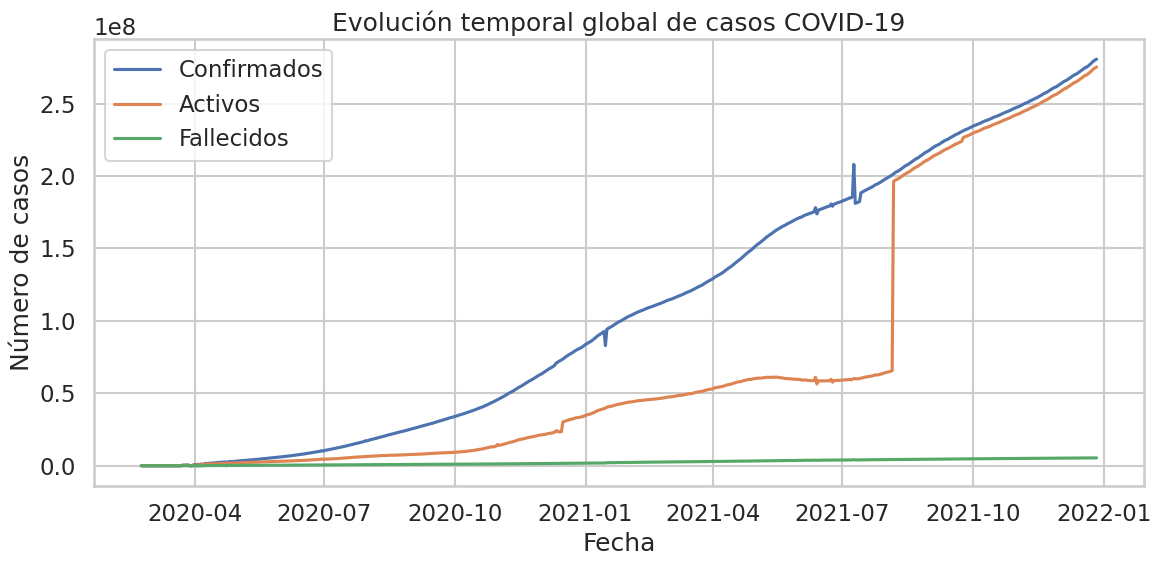

In [ ]:
# 1) Evolución temporal global
time_series = df_plot.groupby(pd.Grouper(key='report_date', freq='D')).agg({
    'confirmed':'sum','active':'sum','deaths':'sum'
}).reset_index().sort_values('report_date')

plt.figure(figsize=(12,6))
plt.plot(time_series['report_date'], time_series['confirmed'], label='Confirmados')
plt.plot(time_series['report_date'], time_series['active'], label='Activos')
plt.plot(time_series['report_date'], time_series['deaths'], label='Fallecidos')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.title('Evolución temporal global de casos COVID-19')
plt.legend()
plt.tight_layout()
plt.show()

# Preparar datos de la última fecha disponible
latest_date = df_plot['report_date'].max()
latest_data = df_plot[df_plot['report_date'] == latest_date].copy()


/tmp/ipykernel_2159/663707385.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top10 = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().reset_index().sort_values('confirmed', ascending=True).tail(10)


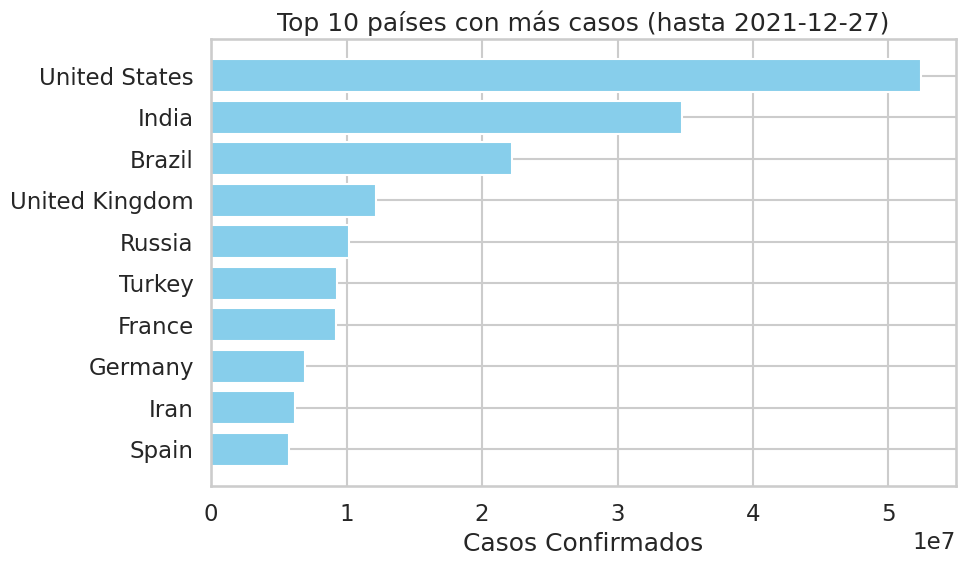

In [ ]:
# 2) Top 10 países por confirmados (usa country_region normalizado)

top10 = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().reset_index().sort_values('confirmed', ascending=True).tail(10)
plt.figure(figsize=(10,6))
plt.barh(top10['country_region'], top10['confirmed'], color='skyblue')
plt.xlabel('Casos Confirmados')
plt.title(f'Top 10 países con más casos (hasta {latest_date.date()})')
plt.tight_layout()
plt.show()

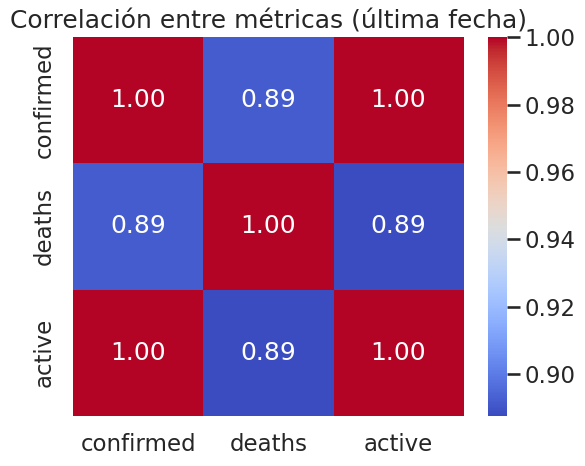

In [ ]:
# 3) Heatmap de correlaciones (última fecha)
corr_cols = ['confirmed','deaths','active']
corr_data = latest_data[corr_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre métricas (última fecha)')
plt.tight_layout()
plt.show()


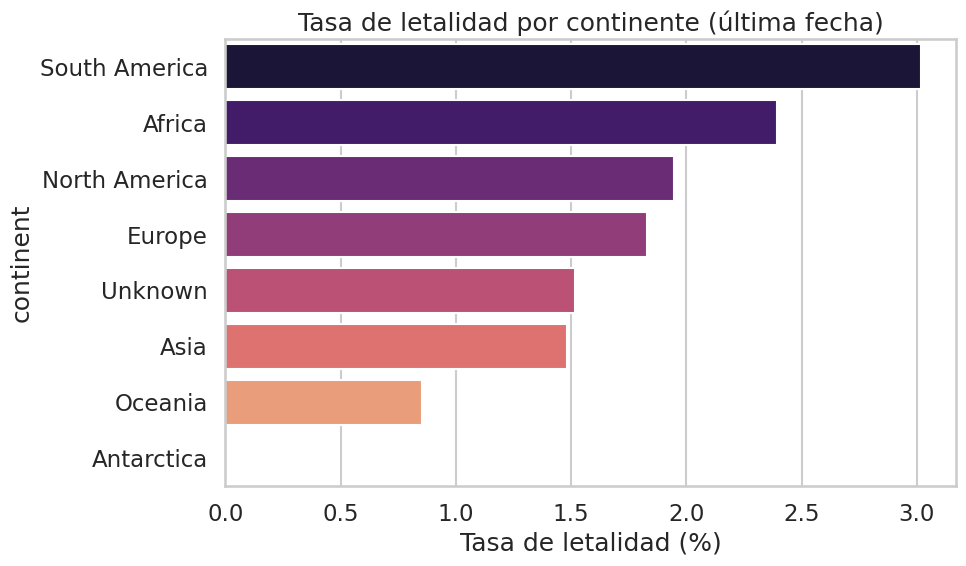

In [ ]:
# 4) Letalidad por continente (intenta resolver continente, si no, marca Unknown)
if 'continent' not in latest_data.columns:
    try:
        import country_converter as coco
        cc = coco.CountryConverter()
        print("Unique countries (first 10):", latest_data['country_region'].unique()[:10])
        latest_data['continent'] = cc.convert(names=latest_data['country_region'].fillna(''), to='continent', not_found='Unknown')
        print("Continents assigned:", latest_data['continent'].unique())
    except Exception as e:
        print(f"Error in continent conversion: {e}")
        latest_data['continent'] = 'Unknown'

# Manual mapping for continents as fallback
manual_continent_map = {
    'United States': 'North America',
    'China': 'Asia',
    'India': 'Asia',
    'Brazil': 'South America',
    'Russia': 'Europe',
    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Germany': 'Europe',
    'Italy': 'Europe',
    'Spain': 'Europe',
    'Mexico': 'North America',
    'Canada': 'North America',
    'Australia': 'Oceania',
    'Japan': 'Asia',
    'South Korea': 'Asia',
    'Korea, South': 'Asia',
    'Argentina': 'South America',
    'Colombia': 'South America',
    'Peru': 'South America',
    'Chile': 'South America',
    'Ecuador': 'South America',
    'Bolivia': 'South America',
    'Venezuela': 'South America',
    'Paraguay': 'South America',
    'Uruguay': 'South America',
    'Guyana': 'South America',
    'Suriname': 'South America',
    'French Guiana': 'South America',
    'Falkland Islands': 'South America',
    'Iran': 'Asia',
    'Turkey': 'Asia',
    'Saudi Arabia': 'Asia',
    'UAE': 'Asia',
    'Israel': 'Asia',
    'Egypt': 'Africa',
    'South Africa': 'Africa',
    'Nigeria': 'Africa',
    'Kenya': 'Africa',
    'Ethiopia': 'Africa',
    'Morocco': 'Africa',
    'Algeria': 'Africa',
    'Tunisia': 'Africa',
    'Libya': 'Africa',
    'Sudan': 'Africa',
    'Chad': 'Africa',
    'Niger': 'Africa',
    'Mali': 'Africa',
    'Burkina Faso': 'Africa',
    'Ghana': 'Africa',
    'Cote d\'Ivoire': 'Africa',
    'Senegal': 'Africa',
    'Guinea': 'Africa',
    'Sierra Leone': 'Africa',
    'Liberia': 'Africa',
    'Togo': 'Africa',
    'Benin': 'Africa',
    'Cameroon': 'Africa',
    'Central African Republic': 'Africa',
    'Congo (Brazzaville)': 'Africa',
    'Congo (Kinshasa)': 'Africa',
    'Gabon': 'Africa',
    'Equatorial Guinea': 'Africa',
    'Sao Tome and Principe': 'Africa',
    'Angola': 'Africa',
    'Zambia': 'Africa',
    'Zimbabwe': 'Africa',
    'Mozambique': 'Africa',
    'Madagascar': 'Africa',
    'Mauritius': 'Africa',
    'Seychelles': 'Africa',
    'Comoros': 'Africa',
    'Mayotte': 'Africa',
    'Reunion': 'Africa',
    'Tanzania': 'Africa',
    'Rwanda': 'Africa',
    'Burundi': 'Africa',
    'Uganda': 'Africa',
    'Djibouti': 'Africa',
    'Eritrea': 'Africa',
    'Somalia': 'Africa',
    'New Zealand': 'Oceania',
    'Papua New Guinea': 'Oceania',
    'Fiji': 'Oceania',
    'Solomon Islands': 'Oceania',
    'Vanuatu': 'Oceania',
    'Samoa': 'Oceania',
    'Tonga': 'Oceania',
    'Tuvalu': 'Oceania',
    'Kiribati': 'Oceania',
    'Marshall Islands': 'Oceania',
    'Micronesia': 'Oceania',
    'Palau': 'Oceania',
    'Nauru': 'Oceania',
    'Norway': 'Europe',
    'Sweden': 'Europe',
    'Finland': 'Europe',
    'Denmark': 'Europe',
    'Iceland': 'Europe',
    'Ireland': 'Europe',
    'Portugal': 'Europe',
    'Netherlands': 'Europe',
    'Belgium': 'Europe',
    'Luxembourg': 'Europe',
    'Switzerland': 'Europe',
    'Austria': 'Europe',
    'Czechia': 'Europe',
    'Poland': 'Europe',
    'Slovakia': 'Europe',
    'Hungary': 'Europe',
    'Slovenia': 'Europe',
    'Croatia': 'Europe',
    'Bosnia and Herzegovina': 'Europe',
    'Serbia': 'Europe',
    'Montenegro': 'Europe',
    'Kosovo': 'Europe',
    'Albania': 'Europe',
    'North Macedonia': 'Europe',
    'Greece': 'Europe',
    'Bulgaria': 'Europe',
    'Romania': 'Europe',
    'Moldova': 'Europe',
    'Ukraine': 'Europe',
    'Belarus': 'Europe',
    'Estonia': 'Europe',
    'Latvia': 'Europe',
    'Lithuania': 'Europe',
    'Kazakhstan': 'Asia',
    'Uzbekistan': 'Asia',
    'Turkmenistan': 'Asia',
    'Kyrgyzstan': 'Asia',
    'Tajikistan': 'Asia',
    'Afghanistan': 'Asia',
    'Pakistan': 'Asia',
    'Bangladesh': 'Asia',
    'Nepal': 'Asia',
    'Bhutan': 'Asia',
    'Sri Lanka': 'Asia',
    'Maldives': 'Asia',
    'Myanmar': 'Asia',
    'Thailand': 'Asia',
    'Cambodia': 'Asia',
    'Laos': 'Asia',
    'Vietnam': 'Asia',
    'Malaysia': 'Asia',
    'Singapore': 'Asia',
    'Indonesia': 'Asia',
    'Philippines': 'Asia',
    'Brunei': 'Asia',
    'Timor-Leste': 'Asia',
    'Mongolia': 'Asia',
    'Taiwan*': 'Asia',
    'Hong Kong': 'Asia',
    'Macau': 'Asia',
    'Cuba': 'North America',
    'Haiti': 'North America',
    'Dominican Republic': 'North America',
    'Jamaica': 'North America',
    'Trinidad and Tobago': 'North America',
    'Barbados': 'North America',
    'Bahamas': 'North America',
    'Saint Lucia': 'North America',
    'Saint Vincent and the Grenadines': 'North America',
    'Grenada': 'North America',
    'Antigua and Barbuda': 'North America',
    'Saint Kitts and Nevis': 'North America',
    'Dominica': 'North America',
    'Panama': 'North America',
    'Costa Rica': 'North America',
    'Nicaragua': 'North America',
    'Honduras': 'North America',
    'El Salvador': 'North America',
    'Guatemala': 'North America',
    'Belize': 'North America',
    'Greenland': 'North America',
    'Bermuda': 'North America',
    'Puerto Rico': 'North America',
    'US Virgin Islands': 'North America',
    'British Virgin Islands': 'North America',
    'Cayman Islands': 'North America',
    'Turks and Caicos Islands': 'North America',
    'Montserrat': 'North America',
    'Anguilla': 'North America',
    'Saint Pierre and Miquelon': 'North America',
    'Saint Barthelemy': 'North America',
    'Saint Martin': 'North America',
    'Guadeloupe': 'North America',
    'Martinique': 'North America',
    'Aruba': 'North America',
    'Curacao': 'North America',
    'Bonaire, Sint Eustatius and Saba': 'North America',
    'Sint Maarten': 'North America',
    'Cabo Verde': 'Africa',
    'Mauritania': 'Africa',
    'Gambia': 'Africa',
    'Guinea-Bissau': 'Africa',
    'Namibia': 'Africa',
    'Botswana': 'Africa',
    'Lesotho': 'Africa',
    'Swaziland': 'Africa',
    'Malawi': 'Africa',
    'Zimbabwe': 'Africa',
    'Western Sahara': 'Africa',
    'Syria': 'Asia',
    'Iraq': 'Asia',
    'Jordan': 'Asia',
    'Lebanon': 'Asia',
    'Palestine': 'Asia',
    'Yemen': 'Asia',
    'Oman': 'Asia',
    'Qatar': 'Asia',
    'Bahrain': 'Asia',
    'Kuwait': 'Asia',
    'Georgia': 'Asia',
    'Armenia': 'Asia',
    'Azerbaijan': 'Asia',
    'Cyprus': 'Asia',
    'Malta': 'Europe',
    'Andorra': 'Europe',
    'Monaco': 'Europe',
    'Liechtenstein': 'Europe',
    'San Marino': 'Europe',
    'Vatican City': 'Europe',
    'Faroe Islands': 'Europe',
    'Gibraltar': 'Europe',
    'Isle of Man': 'Europe',
    'Jersey': 'Europe',
    'Guernsey': 'Europe',
    'Aland Islands': 'Europe',
    'Svalbard and Jan Mayen': 'Europe',
    'Bouvet Island': 'Africa',
    'South Georgia and the South Sandwich Islands': 'South America',
    'Heard Island and McDonald Islands': 'Oceania',
    'French Southern Territories': 'Africa',
    'British Indian Ocean Territory': 'Asia',
    'Christmas Island': 'Asia',
    'Cocos (Keeling) Islands': 'Asia',
    'Norfolk Island': 'Oceania',
    'American Samoa': 'Oceania',
    'Cook Islands': 'Oceania',
    'French Polynesia': 'Oceania',
    'Niue': 'Oceania',
    'Pitcairn': 'Oceania',
    'Tokelau': 'Oceania',
    'Wallis and Futuna': 'Oceania',
    'Wake Island': 'Oceania',
    'Midway Islands': 'Oceania',
    'Johnston Atoll': 'Oceania',
    'Clipperton Island': 'North America',
    'Navassa Island': 'North America',
    'Serranilla Bank': 'North America',
    'Bajo Nuevo Bank': 'North America',
    'Scarborough Reef': 'Asia',
    'Spratly Islands': 'Asia',
    'Paracel Islands': 'Asia',
    'Bassas da India': 'Africa',
    'Europa Island': 'Africa',
    'Glorioso Islands': 'Africa',
    'Juan de Nova Island': 'Africa',
    'Tromelin Island': 'Africa',
    'Ile Saint-Paul': 'Africa',
    'Ile Amsterdam': 'Africa',
    'Crozet Islands': 'Africa',
    'Kerguelen Islands': 'Africa',
    'Saint Helena, Ascension and Tristan da Cunha': 'Africa',
    'Diego Garcia': 'Asia',
    'Chagos Archipelago': 'Asia',
    'Ashmore and Cartier Islands': 'Asia',
    'Coral Sea Islands': 'Oceania',
    'Heard Island': 'Oceania',
    'McDonald Islands': 'Oceania',
    'Macquarie Island': 'Oceania',
    'Lord Howe Island': 'Oceania',
    'Balleny Islands': 'Antarctica',
    'Peter I Island': 'Antarctica',
    'Queen Maud Land': 'Antarctica',
    'Ross Dependency': 'Antarctica',
    'Adelie Land': 'Antarctica',
    'Australian Antarctic Territory': 'Antarctica',
    'British Antarctic Territory': 'Antarctica',
    'Chilean Antarctic Territory': 'Antarctica',
    'Argentine Antarctic Territory': 'Antarctica',
    'Norwegian Antarctic Territory': 'Antarctica',
    'French Antarctic Territory': 'Antarctica',
    'New Zealand Antarctic Territory': 'Antarctica',
    'Australian Antarctic Territory': 'Antarctica',
    'Brazilian Antarctic Territory': 'Antarctica',
    'Peruvian Antarctic Territory': 'Antarctica',
    'Uruguayan Antarctic Territory': 'Antarctica',
    'Ecuadorian Antarctic Territory': 'Antarctica',
    'Chilean Antarctic Territory': 'Antarctica',
    'Argentine Antarctic Territory': 'Antarctica',
    'Norwegian Antarctic Territory': 'Antarctica',
    'French Antarctic Territory': 'Antarctica',
    'New Zealand Antarctic Territory': 'Antarctica',
    'Australian Antarctic Territory': 'Antarctica',
    'Brazilian Antarctic Territory': 'Antarctica',
    'Peruvian Antarctic Territory': 'Antarctica',
    'Uruguayan Antarctic Territory': 'Antarctica',
    'Ecuadorian Antarctic Territory': 'Antarctica',
    'Diamond Princess': 'Unknown',
    'MS Zaandam': 'Unknown',
    'Antarctica': 'Antarctica',
    'Cruise Ship': 'Unknown',
    'Others': 'Unknown'
}
latest_data['continent'] = latest_data['country_region'].map(manual_continent_map).fillna(latest_data['continent'])

letalidad = latest_data.groupby('continent')[['deaths','confirmed']].sum().reset_index()
letalidad['letalidad_pct'] = np.where(letalidad['confirmed']>0,
                                      letalidad['deaths']/letalidad['confirmed']*100, 0.0)

plt.figure(figsize=(10,6))
sns.barplot(data=letalidad.sort_values('letalidad_pct', ascending=False), 
            x='letalidad_pct', y='continent', hue='continent', palette='magma', legend=False)
plt.xlabel('Tasa de letalidad (%)')
plt.title('Tasa de letalidad por continente (última fecha)')
plt.tight_layout()
plt.show()

✓ Mapa cargado desde naturalearth CDN


/tmp/ipykernel_2159/2075946305.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  country_data = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().reset_index()


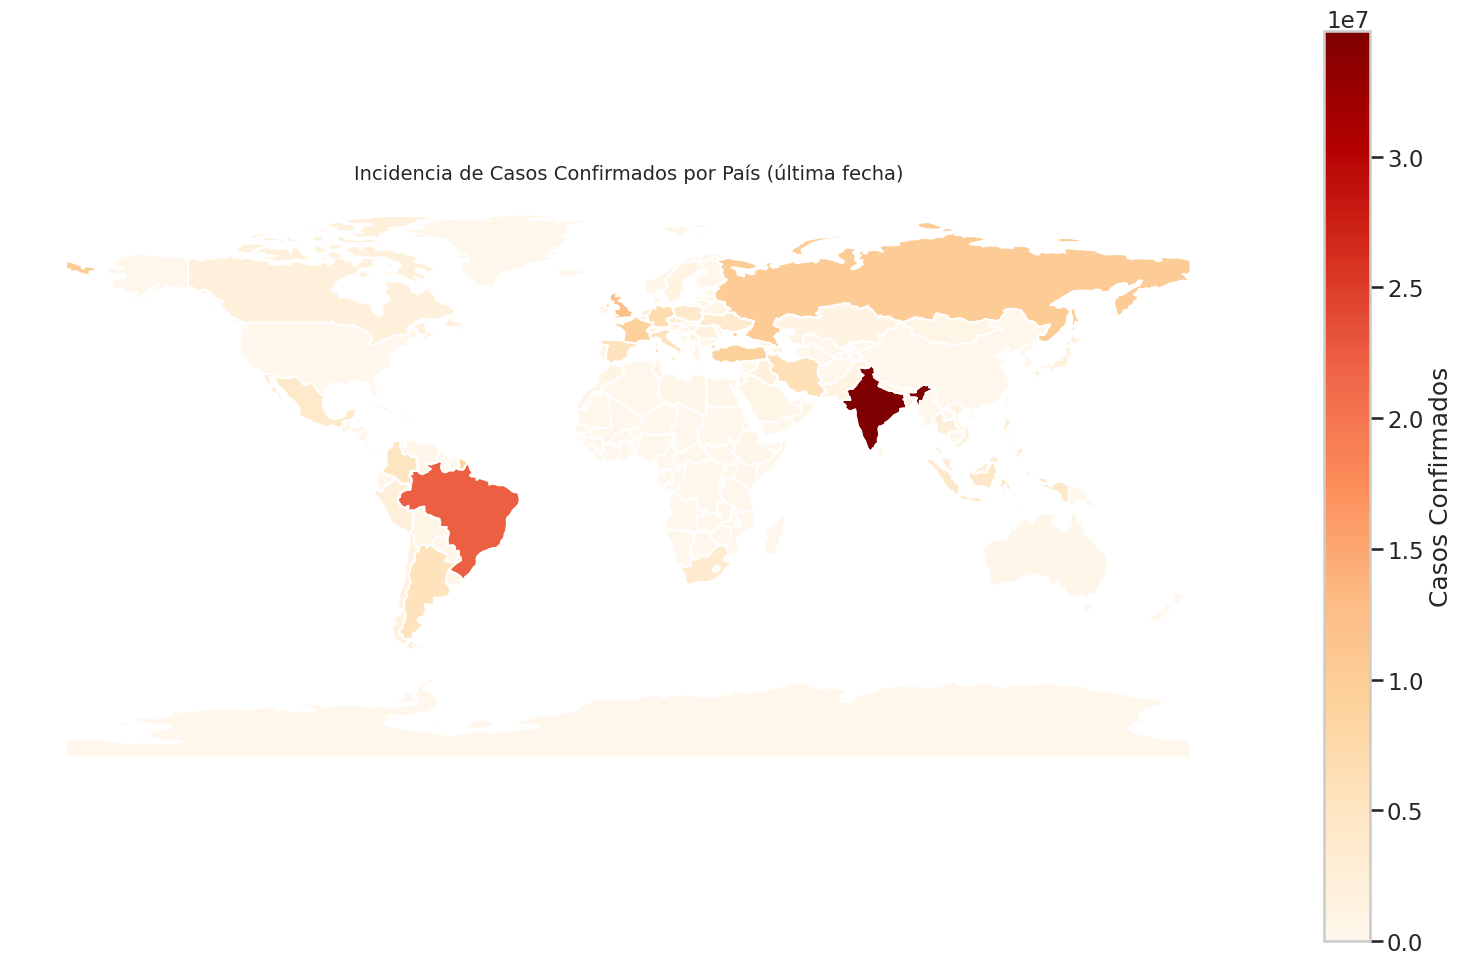

In [ ]:
# 5) Mapa por país (si geopandas disponible) - con múltiples fallbacks
try:
    import geopandas as gpd
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    world = None
    
    # Intento 1: natural earth local (geopandas < 1.0)
    try:
        world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
        print("✓ Mapa cargado desde geopandas.datasets")
    except Exception:
        pass
    
    # Intento 2: geodatasets (geopandas >= 1.0)
    if world is None:
        try:
            import geodatasets
            world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
            print("✓ Mapa cargado desde geodatasets")
        except Exception:
            pass
    
    # Intento 3: GeoJSON con reintentos locales
    if world is None:
        try:
            import requests
            from requests.adapters import HTTPAdapter
            from urllib3.util.retry import Retry
            
            session = requests.Session()
            retries = Retry(total=3, backoff_factor=1.0, status_forcelist=[429,500,502,503,504])
            session.mount("https://", HTTPAdapter(max_retries=retries))
            
            geojson_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
            response = session.get(geojson_url, timeout=20)
            if response.status_code == 200:
                from io import BytesIO
                world = gpd.read_file(BytesIO(response.content))
                print("✓ Mapa cargado desde naturalearth CDN")
        except Exception as e:
            print(f"  (intento 3 falló: {e})")
    
    # Si se cargó el mapa, graficar
    if world is not None:
        country_data = latest_data.groupby('country_region', dropna=False)['confirmed'].sum().reset_index()
        
        # Normalizar nombres de país en world
        if 'NAME' in world.columns:
            world_col = 'NAME'
        elif 'name' in world.columns:
            world_col = 'name'
        elif 'ADMIN' in world.columns:
            world_col = 'ADMIN'
        else:
            world_col = world.columns[0]
        
        # Merge con reintentos de emparejado
        merged = world.merge(country_data, how='left', left_on=world_col, right_on='country_region')
        merged['confirmed'] = merged['confirmed'].fillna(0)
        
        fig, ax = plt.subplots(figsize=(16,10))
        merged.plot(column='confirmed', ax=ax, cmap='OrRd', legend=True,
                   legend_kwds={'label': "Casos Confirmados", 'orientation': "vertical"},
                   missing_kwds={"color": "lightgrey"})
        ax.set_title('Incidencia de Casos Confirmados por País (última fecha)', fontsize=14)
        ax.set_axis_off()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠ No se pudo cargar mapa geográfico. Mostrando tabla alternativa...")
        # Mostrar tabla en lugar del mapa
        country_summary = latest_data.groupby('country_region', dropna=False).agg({
            'confirmed': 'sum',
            'deaths': 'sum',
            'recovered': 'sum'
        }).sort_values('confirmed', ascending=False).head(20)
        print("\nTop 20 Países:")
        print(country_summary)
        
except ImportError:
    print("⚠ geopandas no está instalado. Omitiendo mapa.")
except Exception as e:
    print(f"⚠ Error en mapa: {e}")
    # Fallback: tabla de datos
    country_summary = latest_data.groupby('country_region', dropna=False).agg({
        'confirmed': 'sum',
        'deaths': 'sum',
        'recovered': 'sum'
    }).sort_values('confirmed', ascending=False).head(20)
    print("\nTop 20 Países (fallback):")
    print(country_summary)